#   IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#   LOAD DATA

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,41996,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,22.0,211533,false,0.305,0.8490,...,-10.795,1.0,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4.0,goth
1,76471,5x59U89ZnjZXuNAAlc8X1u,NaN,NaN,"Addio del passato - From ""La traviata""",22.0,196000,FAlSE,NaN,0.1900,...,-12.030,0.0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4.0,opera
2,54809,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,37.0,216506,false,0.583,0.5090,...,-9.661,1.0,2.1000,0.777000,0.202000,0.1150,0.5440,90.459,-1.0,idm
3,16326,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",0.0,218346,NaN,0.163,0.0368,...,-23.149,1.0,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3.0,classical
4,109799,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,27.0,173160,falSE,0.647,0.9210,...,-7.294,1.0,NaN,0.000939,0.371000,0.1310,0.1710,137.981,4.0,techno


In [5]:
test.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4
1,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4
2,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3
3,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3
4,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4


In [6]:
print("Shape of Train : ", train.shape)
print("Shape of Test : ", test.shape)

Shape of Train :  (84800, 21)
Shape of Test :  (34200, 20)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84800 entries, 0 to 84799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        84800 non-null  int64  
 1   track_id          84800 non-null  object 
 2   artists           73336 non-null  object 
 3   album_name        76730 non-null  object 
 4   track_name        84800 non-null  object 
 5   popularity        84710 non-null  object 
 6   duration_ms       84800 non-null  int64  
 7   explicit          77326 non-null  object 
 8   danceability      81484 non-null  float64
 9   energy            79302 non-null  float64
 10  key               84800 non-null  int64  
 11  loudness          80661 non-null  float64
 12  mode              82017 non-null  float64
 13  speechiness       79643 non-null  float64
 14  acousticness      84800 non-null  float64
 15  instrumentalness  81483 non-null  float64
 16  liveness          84233 non-null  float6

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34200 entries, 0 to 34199
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        34200 non-null  int64  
 1   track_id          34200 non-null  object 
 2   artists           34199 non-null  object 
 3   album_name        34199 non-null  object 
 4   track_name        34199 non-null  object 
 5   popularity        34200 non-null  int64  
 6   duration_ms       34200 non-null  int64  
 7   explicit          34200 non-null  bool   
 8   danceability      34200 non-null  float64
 9   energy            34200 non-null  float64
 10  key               34200 non-null  int64  
 11  loudness          34200 non-null  float64
 12  mode              34200 non-null  int64  
 13  speechiness       34200 non-null  float64
 14  acousticness      34200 non-null  float64
 15  instrumentalness  34200 non-null  float64
 16  liveness          34200 non-null  float6

In [9]:
print("Null Values :\n", train.isnull().sum())

Null Values :
 Unnamed: 0              0
track_id                0
artists             11464
album_name           8070
track_name              0
popularity             90
duration_ms             0
explicit             7474
danceability         3316
energy               5498
key                     0
loudness             4139
mode                 2783
speechiness          5157
acousticness            0
instrumentalness     3317
liveness              567
valence                 0
tempo                2102
time_signature       1425
track_genre          1853
dtype: int64


In [10]:
print("Null Values :\n", test.isnull().sum())

Null Values :
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64


In [11]:
print("Total null present in train : ", train.isnull().sum().sum())

Total null present in train :  57255


In [12]:
print("Total null present in train : ", (train.isnull().sum()/train.shape[0])*100)

Total null present in train :  Unnamed: 0           0.000000
track_id             0.000000
artists             13.518868
album_name           9.516509
track_name           0.000000
popularity           0.106132
duration_ms          0.000000
explicit             8.813679
danceability         3.910377
energy               6.483491
key                  0.000000
loudness             4.880896
mode                 3.281840
speechiness          6.081368
acousticness         0.000000
instrumentalness     3.911557
liveness             0.668632
valence              0.000000
tempo                2.478774
time_signature       1.680425
track_genre          2.185142
dtype: float64


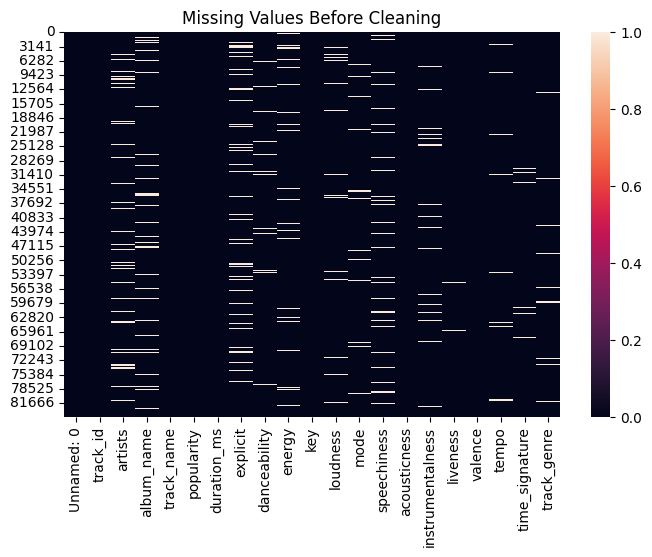

In [13]:
plt.figure(figsize=(8,5))
sns.heatmap(train.isnull(), cbar=True)
plt.title("Missing Values Before Cleaning")
plt.show()


DATA CLEANING START

In [14]:
train_copy = train.copy()
test_copy = test.copy()

In [15]:
# check duplicate

train_copy.duplicated().sum()

# so we have a 92 duplicated value in the whole data set 

np.int64(92)

In [16]:
# remove the duplicate
train_copy= train_copy.drop_duplicates()

In [17]:
# no duplicate present
print("After removing Duplicate the Shape will be :", train_copy.shape)

After removing Duplicate the Shape will be : (84708, 21)


In [18]:
# Remove useless columns
drop_cols = ["track_id", "track_name","Unnamed: 0"]
train_copy = train.drop(columns=drop_cols)
test_copy = test.drop(columns=drop_cols)


In [19]:
# Fill missing
for col in ["artists", "album_name"]:
    train_copy[col] = train_copy[col].fillna("Unknown")
    test_copy[col] = test_copy[col].fillna("Unknown")

In [20]:
train_copy["popularity"] = pd.to_numeric(train_copy["popularity"], errors='coerce')
test_copy["popularity"] = pd.to_numeric(test_copy["popularity"], errors='coerce')

train_copy["popularity"].fillna(train_copy["popularity"].median(), inplace=True)
test_copy["popularity"].fillna(train_copy["popularity"].median(), 
inplace=True)


In [21]:
train_copy["explicit"].unique()

array(['false', 'FAlSE', nan, 'falSE', '0', 'False', 'True', 'TrUe',
       'FALSE', 'FalSE', 'true', 'TRUe', 'TRUE', '1'], dtype=object)

In [22]:
train_copy["explicit"] = train_copy["explicit"].map({True:1, False:0}).fillna(0)
test_copy["explicit"] = test_copy["explicit"].map({True:1, False:0}).fillna(0)

In [23]:
num_cols = [
    "danceability","energy","loudness","speechiness",
    "instrumentalness","liveness","tempo"
]

for col in num_cols:
    train_copy[col] = train_copy[col].fillna(train_copy[col].median())
    test_copy[col] = test_copy[col].fillna(test_copy[col].median())

In [24]:
mode_time = ["mode","time_signature"]
for col in mode_time:
    train_copy[col] = train_copy[col].fillna(train_copy[col].mode()[0])
    test_copy[col] = test_copy[col].fillna(test_copy[col].mode()[0])

In [25]:
train_copy = train_copy.dropna(subset=["track_genre"])
 

In [26]:
train_copy.isnull().sum()

artists             0
album_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

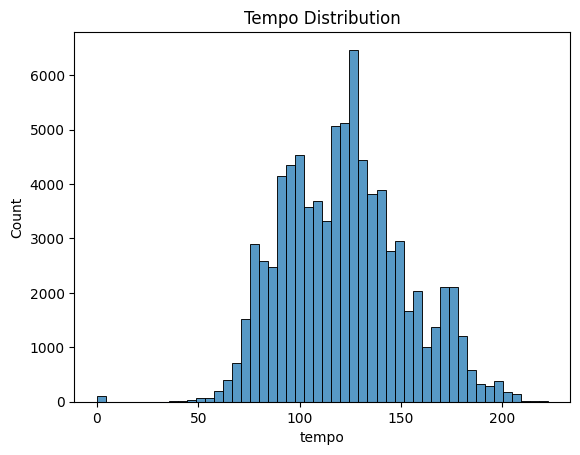

In [27]:
# Visualization: Feature distribution
sns.histplot(train["tempo"], bins=50)
plt.title("Tempo Distribution")
plt.show()

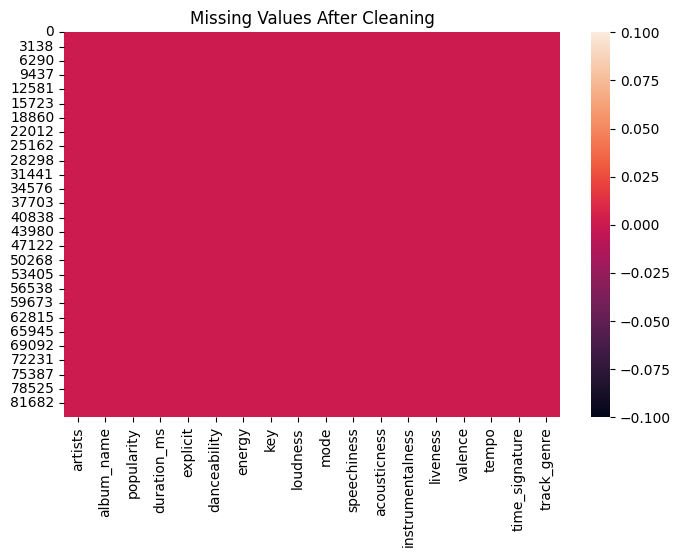

In [28]:
plt.figure(figsize=(8,5))
sns.heatmap(train_copy.isnull(), cbar=True)
plt.title("Missing Values After Cleaning")
plt.show()

DATA IS CLEANED

# FEATURE ENGINEERING  START

In [29]:
def process_artists(df):
    df["num_artists"] = df["artists"].apply(lambda x: len(str(x).split(";")))
    df["main_artist"] = df["artists"].apply(lambda x: str(x).split(";")[0])
    return df

train_copy = process_artists(train_copy)
test_copy = process_artists(test_copy)

artist_freq = train_copy["main_artist"].value_counts().to_dict()


In [30]:
train_copy["artist_freq"] = train_copy["main_artist"].map(artist_freq)
test_copy["artist_freq"] = test_copy["main_artist"].map(artist_freq)

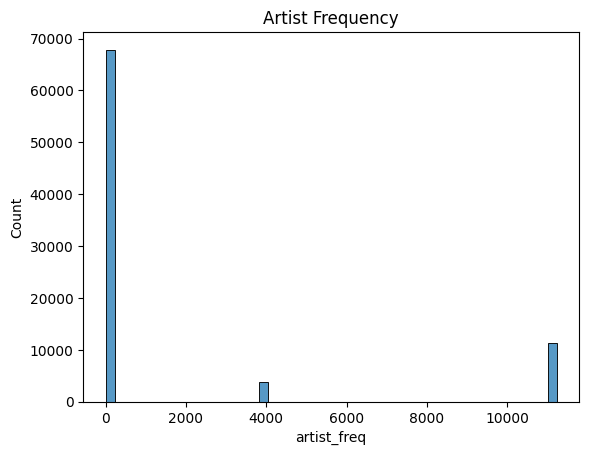

In [31]:
# Visualization: Artist frequency distribution
sns.histplot(train_copy["artist_freq"], bins=50)
plt.title("Artist Frequency")
plt.show()

In [ ]:
display(train_copy[["artists","num_artists","main_artist","artist_freq"]].sample(10))

,artists,num_artists,main_artist,artist_freq
78160,New Order,1,New Order,12
79409,Fernando Corona,1,Fernando Corona,7
20719,anirap,1,anirap,6
19699,The Devil Makes Three,1,The Devil Makes Three,12
25915,Above & Beyond;Zoë Johnston,2,Above & Beyond,34
76175,Unknown,1,Unknown,11231
49412,Womack & Womack,1,Womack & Womack,1
23209,Badfinger,1,Badfinger,23
18118,Wu-Tang Clan;RZA;Inspectah Deck;Method Man,4,Wu-Tang Clan,8
78086,Burna Boy;Lily Allen,2,Burna Boy,123


In [33]:
test_copy["artist_freq"].fillna(0, inplace=True)

In [34]:
# Album frequency
album_freq = train_copy["album_name"].value_counts().to_dict()

train_copy["album_freq"] = train_copy["album_name"].map(album_freq)
test_copy["album_freq"] = test_copy["album_name"].map(album_freq)

In [35]:
display(train_copy[["main_artist","num_artists","album_freq"]].sample(10).sort_values("album_freq",ascending=False))

,main_artist,num_artists,album_freq
83349,Abdul Hannan,2,7882
58155,Ella Fitzgerald,1,43
7888,Kacey Musgraves,2,30
77756,HUGEL,2,12
84444,Unknown,1,9
31567,Todd Glass,1,6
72576,Unknown,1,5
49643,Unknown,1,4
38592,Digicult,2,2
17265,REO Speedwagon,1,1


In [36]:
# Drop raw columns
train_copy.drop(columns=["artists", "album_name"], inplace=True)
test_copy.drop(columns=["artists", "album_name"], inplace=True)

# FEATURE ENGINEERING  DONE

In [37]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix,precision_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [38]:
# Fit on train
le_artist = LabelEncoder()
le_artist.fit(train_copy["main_artist"])

# Convert test safely
test_copy["main_artist"] = test_copy["main_artist"].apply(
    lambda x: x if x in le_artist.classes_ else "unknown"
)

# Add "unknown" to encoder
le_artist.classes_ = np.append(le_artist.classes_, "unknown")

# Transform
train_copy["main_artist"] = le_artist.transform(train_copy["main_artist"])
test_copy["main_artist"] = le_artist.transform(test_copy["main_artist"])

In [39]:
# Encode target
le_target = LabelEncoder()
train_copy["track_genre"] = le_target.fit_transform(train_copy["track_genre"])

#   SPLIT DATA

In [40]:
X = train_copy.drop("track_genre", axis=1)
y = train_copy["track_genre"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [41]:
lgb = LGBMClassifier(
    n_estimators=700,                          # number of trees
    learning_rate=0.05,                        # step size for learning
    max_depth=8,                      # control tree depth (avoid overfitting)
    random_state=42,                           # random_state
    min_gain_to_split=0.01,      #control tree growth and prevent overfitting 
    verbose = -1                               # hide training logs      
)

xgb = XGBClassifier(
    n_estimators=500,                          # number of trees
    learning_rate=0.05,                        # step size for learning
    max_depth=6,                      # control tree depth (avoid overfitting)
    random_state=42,                  # random_state
    use_label_encoder=False,
    eval_metric="mlogloss",           #evaluate a model's performance
    verbosity = 0                   #logging information 
)


#   TRAIN MODELS


In [42]:

lgb.fit(X_train, y_train)
xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


 
#   VALIDATION PREDICTIONS

In [43]:

 
lgb_pred = lgb.predict_proba(X_val)
xgb_pred = xgb.predict_proba(X_val)

In [44]:
# ENSEMBLE
final_pred = (0.6 * lgb_pred + 0.4 * xgb_pred)
final_pred = np.argmax(final_pred, axis=1)


 
# EVALUATION

In [45]:

 
print("Validation Accuracy:", accuracy_score(y_val, final_pred))
print("Validation F1 Score:", f1_score(y_val, final_pred, average='weighted'))
print("Validation Precision:", precision_score(y_val, final_pred, average='weighted'))

Validation Accuracy: 0.44478601567209164
Validation F1 Score: 0.44363308274512325
Validation Precision: 0.4464636216130885


# Confusion Matrix

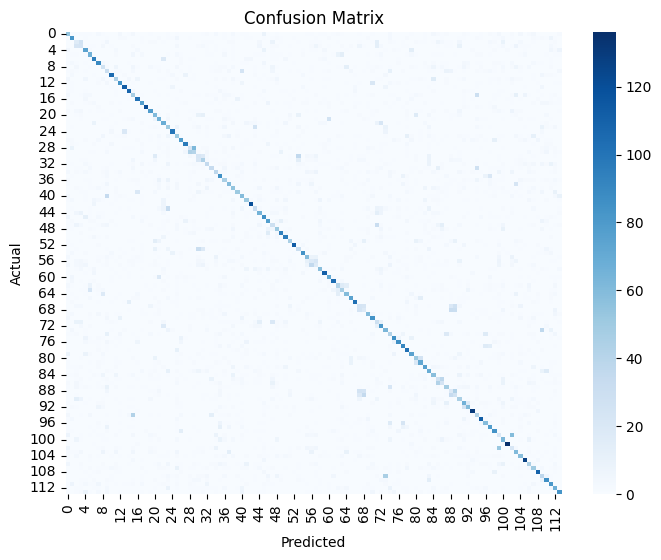

In [ ]:

cm = confusion_matrix(y_val, final_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

CROSS VALIDATION 
Using StratifiedKFold to ensure equal class distribution
Evaluating model stability across multiple splits

In [ ]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# LightGBM model (fast + efficient for tabular data)

lgb_fast = LGBMClassifier(
    n_estimators=200,        # number of trees 
    learning_rate=0.05,      # step size for learning
    max_depth=8,             # control tree depth (avoid overfitting)
    verbose=-1               # hide training logs
)
  
  
# Store F1 scores of each fold
cv_scores = []




# Loop through each fold (different train-validation split each time)

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"Fold {i+1} running...")



    # Split data into training and validation for current fold
    
    X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]




    # Train model on training split and validate on validation split
    
    lgb_fast.fit(
        X_t, y_t,
        eval_set=[(X_v, y_v)],          # validation data for monitoring
        eval_metric="multi_logloss",    # metric for multi-class classification
        callbacks=[]
    )

    pred = lgb_fast.predict(X_v)
    
    
    # Calculate F1 score (handles class imbalance)
    score = (f1_score(y_v, pred, average='weighted'))
    print(f"Fold {i+1} F1:", score)
    
    
    # Calculate Precision (how accurate predictions are)
    precision = precision_score(y_v, pred, average='weighted')
    print(f"Fold {i+1} Precision:", precision)
    cv_scores.append(score)


# Final average F1 score across all folds (model stability)
print("Final CV F1:", np.mean(cv_scores))


NameError: name 'StratifiedKFold' is not defined

In [48]:

#   FINAL TRAIN ON FULL DATA
 
lgb.fit(X, y)
xgb.fit(X, y)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [49]:
#   TEST PREDICTION
 
lgb_test = lgb.predict_proba(test_copy)
xgb_test = xgb.predict_proba(test_copy)

final_test = (0.6 * lgb_test + 0.4 * xgb_test)
final_test = np.argmax(final_test, axis=1)


# convert in original form

In [50]:
original_labels = le_target.inverse_transform(final_test)

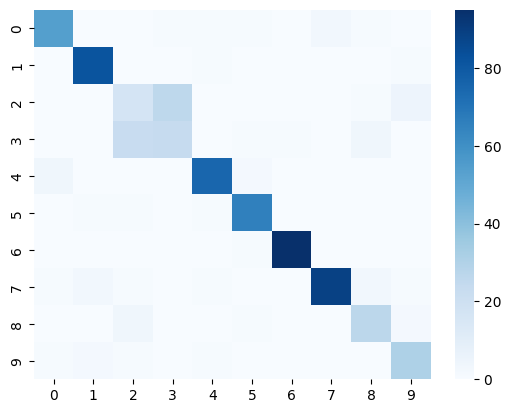

In [51]:
top_classes = np.unique(y_val)[:10]
cm_small = confusion_matrix(y_val, final_pred, labels=top_classes)

sns.heatmap(cm_small, cmap="Blues")
plt.show()

# Predicted Genre Sample

In [52]:

result_df = pd.DataFrame({
    "Predicted_Genre": original_labels
})

display(result_df.sample(10))

,Predicted_Genre
4844,honky-tonk
8161,emo
30335,cantopop
25617,sad
13684,latino
10423,j-pop
28996,kids
2775,dub
33100,anime
19206,jazz


# Final Result in this File

In [53]:
submission = pd.DataFrame({
    "track_genre": original_labels
})

submission.to_csv("DataSprint_Submission.csv", index=False)

print(" FINAL SUBMISSION READY!")

 FINAL SUBMISSION READY!
